In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e11/sample_submission.csv
/kaggle/input/playground-series-s5e11/train.csv
/kaggle/input/playground-series-s5e11/test.csv


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve, 
    accuracy_score,
    f1_score
)
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression
# from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


In [13]:
base_path = r'/kaggle/input/playground-series-s5e11/'
train_path = base_path + 'train.csv'
test_path = base_path + 'test.csv'

In [14]:
raw_df = pd.read_csv(train_path)

In [15]:
cat = [i for i in raw_df.columns if raw_df[i].dtype == "object"]
target = "loan_paid_back"
num = [i for i in raw_df.columns if i not in (cat + [target, "id"])]
base = [col for col in raw_df.columns if col not in ['id', target]]

print("Categorical Features: ", cat)
print("Numerical Features: ", num)
print("Target Feature: ", [target])
print("Base Features", base)

Categorical Features:  ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
Numerical Features:  ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
Target Feature:  ['loan_paid_back']
Base Features ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']


In [16]:
# Some added Featuure Engineering
# financial feature engineering
def feature_engnineering(raw_df):
    featured_df = raw_df.copy()
    featured_df['credit_utilization'] = featured_df['loan_amount'] / featured_df['annual_income']
    featured_df['interest_burden'] = featured_df['interest_rate'] * featured_df['loan_amount'] / 100
    featured_df['is_employed_flag'] = featured_df['employment_status'].apply(lambda x: 0 if x in ['Unemployed', 'Student', 'Retired'] else 1)
    featured_df['debt_intrest'] = featured_df['debt_to_income_ratio'] * featured_df['interest_rate'] / 100
    featured_df['credit_debt_interaction'] = featured_df['credit_score'] * featured_df['debt_to_income_ratio']
    
    # Example: Tagging high risk
    featured_df['high_risk_combo'] = (
        (featured_df['employment_status'].isin(['Unemployed', 'Student'])) &
        (featured_df['education_level'].isin(['High School', 'Other'])) &
        (featured_df['marital_status'].isin(['Single', 'Divorced', 'Widowed'])) &
        (featured_df['loan_purpose'].isin(['Medical', 'Education', 'Vacation', 'Other'])) &
        (featured_df['grade_subgrade'].str[0].isin(['D', 'E', 'F']))
    )
    return featured_df
    

In [17]:
# After feature engineering
feature_df = feature_engnineering(raw_df)
feature_df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,credit_utilization,interest_burden,is_employed_flag,debt_intrest,credit_debt_interaction,high_risk_combo
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,0.086094,345.635014,1,0.011483,61.824,False
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0,0.207757,593.428520,1,0.021447,105.576,False
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,0.343080,1659.702640,1,0.009467,67.318,False
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,0.099929,753.879280,1,0.010465,34.645,False
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,0.477883,1244.030303,1,0.005411,35.245,False


In [18]:
feature_df.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back', 'credit_utilization',
       'interest_burden', 'is_employed_flag', 'debt_intrest',
       'credit_debt_interaction', 'high_risk_combo'],
      dtype='object')

In [19]:
feature_num = ['annual_income', 'debt_to_income_ratio', 'credit_score',
               'loan_amount', 'interest_rate', 
               'credit_utilization', 'interest_burden', 'is_employed_flag',
               'debt_intrest', 'credit_debt_interaction', 'high_risk_combo'
              ]
feature_cat = ['gender', 'marital_status', 'education_level', 
               'employment_status', 'loan_purpose', 'grade_subgrade'
              ]
FEATURES = feature_num + feature_cat

In [20]:
train = feature_df.copy()
X = train[FEATURES]
y = train[target]
CATS = feature_cat.copy()
test = feature_engnineering(pd.read_csv(test_path))

# Search For Best Params

In [27]:
# =============================
# LightGBM Binary Classification Pipeline (Imbalanced Data)
# =============================

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, classification_report

In [28]:
# -----------------------------
# 1. Load or define your data
# -----------------------------
# Example: replace with your dataset
# X = your feature matrix (pd.DataFrame or np.array)
# y = your target (pd.Series or np.array)
# e.g., X, y = df.drop('target', axis=1), df['target']
X[CATS] = X[CATS].astype('category')
# -----------------------------
# 2. Stratified Split
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train size:", X_train.shape, "Val size:", X_val.shape, "Test size:", X_test.shape)
print("Class balance in train:", np.bincount(y_train))
print("Class balance in val:", np.bincount(y_val))
print("Class balance in test:", np.bincount(y_test))

Train size: (415795, 17) Val size: (89099, 17) Test size: (89100, 17)
Class balance in train: [ 83650 332145]
Class balance in val: [17925 71174]
Class balance in test: [17925 71175]


In [29]:
# -----------------------------
# 3. Compute imbalance ratio
# -----------------------------
# scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
scale_pos_weight = np.sum(y_train == 1) / np.sum(y_train == 0) # TO enforce more on true negatives
print("scale_pos_weight:", scale_pos_weight) # should be about 3.97

scale_pos_weight: 3.9706515242080096


In [31]:
# -----------------------------
# 4. Define Base Model
# -----------------------------
base_model = lgb.LGBMClassifier(
    device='gpu',
    objective='binary',
    boosting_type='gbdt',
    random_state=42,
    n_jobs=-1,
    metric='auc' #,
    # scale_pos_weight=scale_pos_weight
)


## Best params without passing auc metric to classifier
```
Best Parameters: {
    'subsample': 1.0,
    'reg_lambda': 0,
    'reg_alpha': 0.5,
    'num_leaves': 31,
    'n_estimators': 300,
    'min_child_samples': 20,
    'max_depth': 10,
    'learning_rate': 0.1,
    'device': 'gpu',
    'colsample_bytree': 0.6
}
Best CV AUC: 0.9213154023202099
```

In [39]:
# -----------------------------
# 8. Evaluate on Validation Set
# -----------------------------
# best_model = random_search.best_estimator_

# y_val_prob = best_model.predict_proba(X_val)[:, 1]
# threshold = 0.5
# print("For:", threshold)
# y_val_pred = (y_val_prob > threshold).astype(int)
# # threshold = threshold + (i/1000)
# print("\nValidation Metrics:")
# print("ROC AUC:", roc_auc_score(y_val, y_val_prob))
# print("PR AUC:", average_precision_score(y_val, y_val_prob))
# print("F1 Score:", f1_score(y_val, y_val_pred))
# print("\nClassification Report:")
# print(classification_report(y_val, y_val_pred))

# # Beautify Confusion Matrix with labels
# conf_matrix = confusion_matrix(y_val,y_val_pred)
# df_cm = pd.DataFrame(
#     conf_matrix, 
#     index=["Actual Negative", "Actual Positive"], 
#     columns=["Predicted Negative", "Predicted Positive"]
# )
# print("Confusion Matrix:")
# print(df_cm)
# print("*" * 40)

For: 0.5

Validation Metrics:
ROC AUC: 0.9208336165883213
PR AUC: 0.9746816921134944
F1 Score: 0.93894491185499

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.51      0.66     17925
         1.0       0.89      0.99      0.94     71174

    accuracy                           0.90     89099
   macro avg       0.93      0.75      0.80     89099
weighted avg       0.90      0.90      0.88     89099

Confusion Matrix:
                 Predicted Negative  Predicted Positive
Actual Negative                9079                8846
Actual Positive                 363               70811
****************************************


In [41]:
# -----------------------------
# 9. Final Evaluation on Test Set
# -----------------------------
# y_test_prob = best_model.predict_proba(X_test)[:, 1]
# y_test_pred = (y_test_prob > 0.5).astype(int)

# print("\nTest Metrics:")
# print("ROC AUC:", roc_auc_score(y_test, y_test_prob)) 
# print("PR AUC:", average_precision_score(y_test, y_test_prob))


Test Metrics:
ROC AUC: 0.9220637157025993
PR AUC: 0.9752521081301554


In [42]:
# print("\nBest Parameters:")
# print(random_search.best_params_)
# print("Best CV AUC:", random_search.best_score_)


Best Parameters:
{'subsample': 0.8, 'scale_pos_weight': 3.9706515242080096, 'reg_lambda': 0, 'reg_alpha': 0.5, 'num_leaves': 15, 'n_estimators': 1000, 'min_child_samples': 75, 'max_depth': -1, 'learning_rate': 0.1, 'device': 'gpu', 'colsample_bytree': 0.6}
Best CV AUC: 0.921283434019686


In [43]:
opt_params = {
    'subsample': 0.8, 
    'reg_lambda': 0, 
    'reg_alpha': 0.5, 
    'num_leaves': 15, 
    'n_estimators': 1000, 
    'min_child_samples': 75, 
    'max_depth': -1, 
    'learning_rate': 0.1, 
    'device': 'gpu', 
    'colsample_bytree': 0.6
}

In [60]:
best_params = random_search.best_params_

final_model = lgb.LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    random_state=42,
    # scale_pos_weight=scale_pos_weight,
    **best_params
)

final_model.fit(X,y,eval_metric='auc')

[LightGBM] [Info] Number of positive: 474494, number of negative: 119500
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2357
[LightGBM] [Info] Number of data points in the train set: 593994, number of used features: 17
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 14 dense feature groups (9.06 MB) transferred to GPU in 0.011922 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798820 -> initscore=1.378933
[LightGBM] [Info] Start training from score 1.378933


LGBMClassifier(colsample_bytree=0.6, device='gpu', max_depth=10,
               n_estimators=300, objective='binary', random_state=42,
               reg_alpha=0.5, reg_lambda=0,
               scale_pos_weight=0.25184783754083306)

In [46]:
# best_params = random_search.best_params_

# final_model = lgb.LGBMClassifier(
#     objective='binary',
#     boosting_type='gbdt',
#     random_state=42,
#     # scale_pos_weight=scale_pos_weight,
#     **best_params
# )

# final_model.fit(X,y,eval_metric='auc')

[LightGBM] [Info] Number of positive: 474494, number of negative: 119500
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2357
[LightGBM] [Info] Number of data points in the train set: 593994, number of used features: 17
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 14 dense feature groups (9.06 MB) transferred to GPU in 0.012041 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798820 -> initscore=1.378933
[LightGBM] [Info] Start training from score 1.378933


LGBMClassifier(colsample_bytree=0.6, device='gpu', min_child_samples=75,
               n_estimators=1000, num_leaves=15, objective='binary',
               random_state=42, reg_alpha=0.5, reg_lambda=0,
               scale_pos_weight=3.9706515242080096, subsample=0.8)

In [49]:
id_df = test["id"]
test_df = test.drop(columns="id")
ans_df = final_model.predict_proba(test_df)[:, 1]
pd.DataFrame({"id":id_df, "loan_paid_back": ans_df}).to_csv("lgb_opt_ans01.csv", index = False)

In [ ]:
pd.DataFrame({"id":id_df, "loan_paid_back": ans_df})

In [51]:
ans_full = final_model.predict_proba(test_df)

In [22]:
# Check Masaya code

In [24]:
best_params = {'subsample': 0.8,
 'scale_pos_weight': 3.9706515242080096,
 'reg_lambda': 0,
 'reg_alpha': 0.5,
 'num_leaves': 15,
 'n_estimators': 1000,
 'min_child_samples': 75,
 'max_depth': -1,
 'learning_rate': 0.1,
 'device': 'gpu',
 'colsample_bytree': 0.6}

## Results with gdbt boosting
```
--- Fold 1/5 ---
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2357
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 17
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 14 dense feature groups (7.25 MB) transferred to GPU in 0.011793 secs. 1 sparse feature groups
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798819 -> initscore=1.378932
[LightGBM] [Info] Start training from score 1.378932
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[970]	valid_0's auc: 0.923203	valid_0's binary_logloss: 0.296168
Fold 1 AUC: 0.9232
              precision    recall  f1-score   support

         0.0       0.97      0.51      0.67     23900
         1.0       0.89      1.00      0.94     94899

    accuracy                           0.90    118799
   macro avg       0.93      0.75      0.80    118799
weighted avg       0.91      0.90      0.89    118799

--- Fold 2/5 ---
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2357
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 17
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 14 dense feature groups (7.25 MB) transferred to GPU in 0.011864 secs. 1 sparse feature groups
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798819 -> initscore=1.378932
[LightGBM] [Info] Start training from score 1.378932
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[702]	valid_0's auc: 0.92249	valid_0's binary_logloss: 0.298522
Fold 2 AUC: 0.9225
              precision    recall  f1-score   support

         0.0       0.96      0.51      0.67     23900
         1.0       0.89      1.00      0.94     94899

    accuracy                           0.90    118799
   macro avg       0.93      0.75      0.80    118799
weighted avg       0.90      0.90      0.88    118799

--- Fold 3/5 ---
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2357
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 17
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 14 dense feature groups (7.25 MB) transferred to GPU in 0.012106 secs. 1 sparse feature groups
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798819 -> initscore=1.378932
[LightGBM] [Info] Start training from score 1.378932
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[740]	valid_0's auc: 0.921287	valid_0's binary_logloss: 0.297744
Fold 3 AUC: 0.9213
              precision    recall  f1-score   support

         0.0       0.96      0.52      0.67     23900
         1.0       0.89      0.99      0.94     94899

    accuracy                           0.90    118799
   macro avg       0.93      0.76      0.81    118799
weighted avg       0.91      0.90      0.89    118799

--- Fold 4/5 ---
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2356
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 17
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 14 dense feature groups (7.25 MB) transferred to GPU in 0.011532 secs. 1 sparse feature groups
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798819 -> initscore=1.378932
[LightGBM] [Info] Start training from score 1.378932
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[809]	valid_0's auc: 0.922251	valid_0's binary_logloss: 0.297074
Fold 4 AUC: 0.9223
              precision    recall  f1-score   support

         0.0       0.97      0.51      0.67     23900
         1.0       0.89      1.00      0.94     94899

    accuracy                           0.90    118799
   macro avg       0.93      0.75      0.80    118799
weighted avg       0.91      0.90      0.89    118799

--- Fold 5/5 ---
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Number of positive: 379596, number of negative: 95600
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2357
[LightGBM] [Info] Number of data points in the train set: 475196, number of used features: 17
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 14 dense feature groups (7.25 MB) transferred to GPU in 0.011411 secs. 1 sparse feature groups
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798820 -> initscore=1.378935
[LightGBM] [Info] Start training from score 1.378935
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[612]	valid_0's auc: 0.921341	valid_0's binary_logloss: 0.2968
Fold 5 AUC: 0.9213
              precision    recall  f1-score   support

         0.0       0.97      0.52      0.67     23900
         1.0       0.89      1.00      0.94     94898

    accuracy                           0.90    118798
   macro avg       0.93      0.76      0.81    118798
weighted avg       0.91      0.90      0.89    118798

====================
Overall OOF AUC: 0.9221
====================
```

In [ ]:
N_SPLITS=5
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'--- Fold {fold}/{N_SPLITS} ---')
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    X_test = test[FEATURES].copy()

    X_train[CATS] = X_train[CATS].astype('category')
    X_val[CATS] = X_val[CATS].astype('category')
    X_test[CATS] = X_test[CATS].astype('category')

    model = LGBMClassifier(objective='binary',
    boosting_type='dart',
    random_state=42,
    early_stopping_rounds=50,
    # scale_pos_weight=scale_pos_weight,
    # verbose=1000,                           
    **best_params)
    
    model.fit(
        X_train, 
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
    )

    val_preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds
    
    fold_score = roc_auc_score(y_val, val_preds)
    print(f'Fold {fold} AUC: {fold_score:.4f}')
    test_preds += model.predict_proba(X_test)[:, 1] / N_SPLITS
    print(classification_report(y_val, (val_preds >= 0.5).astype(int)))

overall_auc = roc_auc_score(y, oof_preds)
print(f'====================')
print(f'Overall OOF AUC: {overall_auc:.4f}')
print(f'====================')


--- Fold 1/5 ---
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2357
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 17
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 14 dense feature groups (7.25 MB) transferred to GPU in 0.011098 secs. 1 sparse feature groups
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798819 -> initscore=1.378932
[LightGBM] [Info] Start training from s

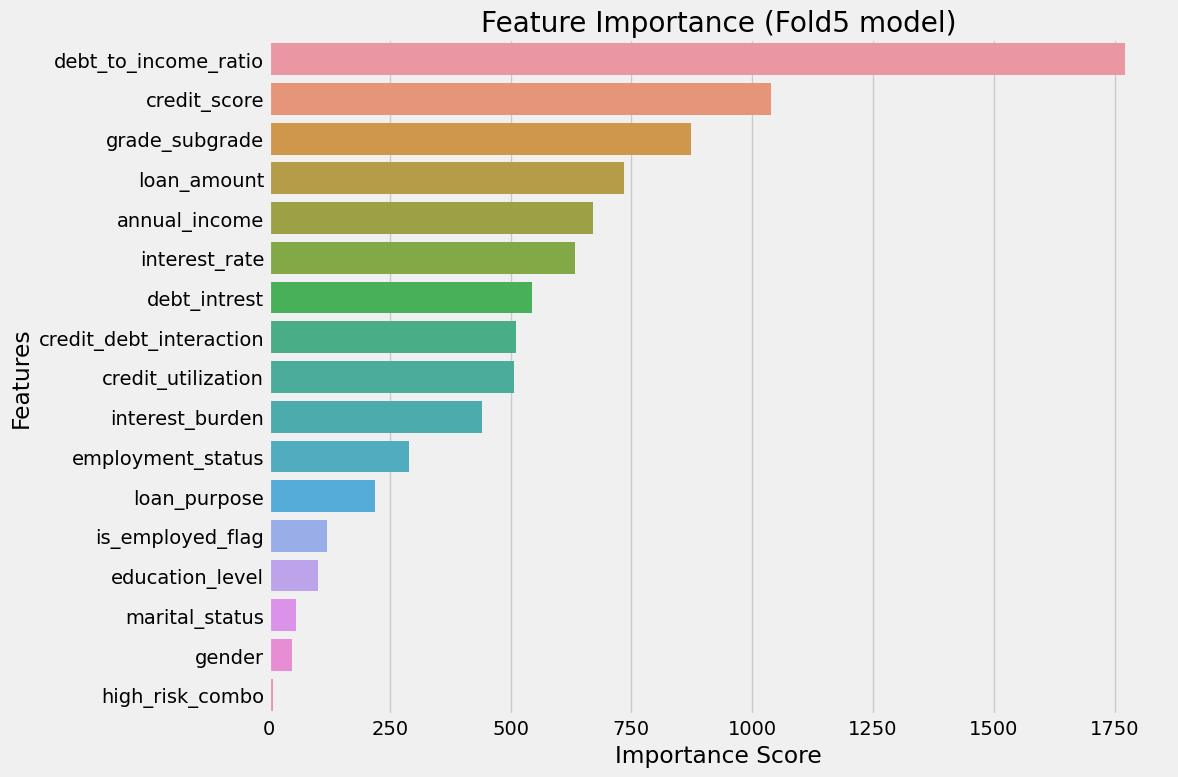

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

feature_importances = model.feature_importances_

importance_df = pd.DataFrame({
    'feature': FEATURES, 
    'importance': feature_importances
})

importance_df = importance_df.sort_values('importance', ascending=False)

plt.style.use('fivethirtyeight')
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', 
            y='feature', 
            data=importance_df.head(50)) 
plt.title('Feature Importance (Fold5 model)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


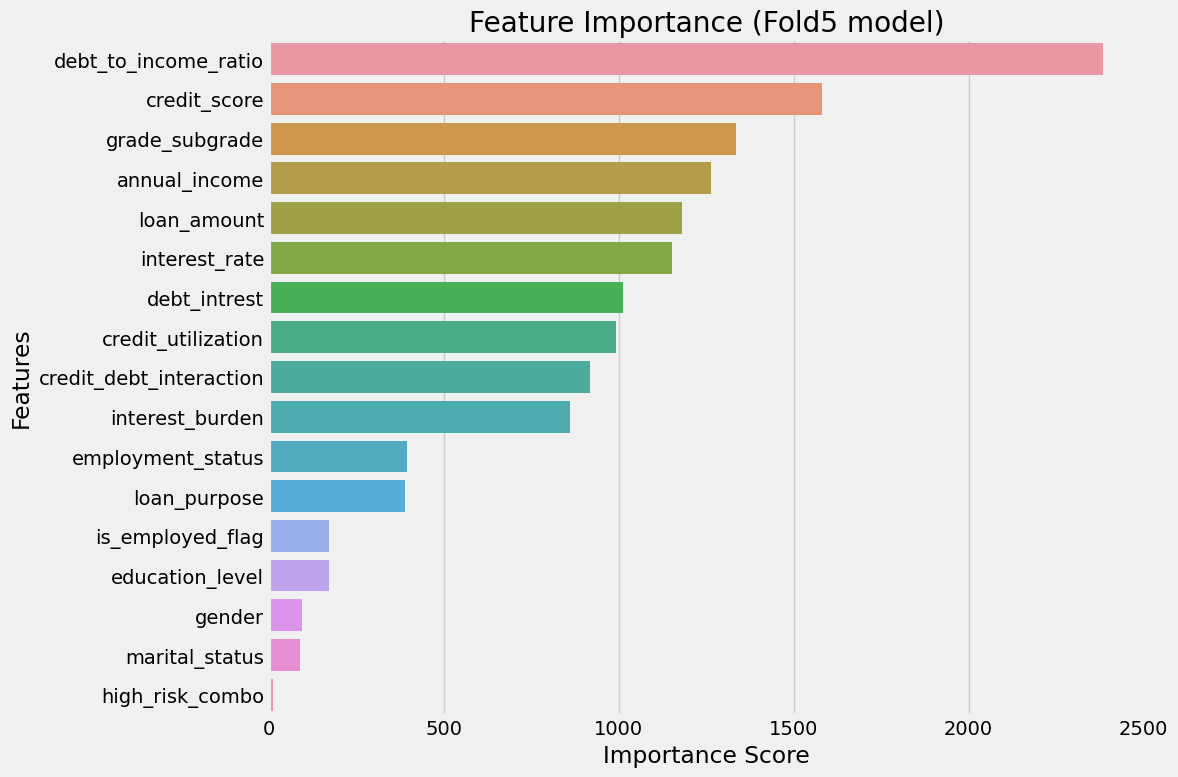

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

feature_importances = model.feature_importances_

importance_df = pd.DataFrame({
    'feature': FEATURES, 
    'importance': feature_importances
})

importance_df = importance_df.sort_values('importance', ascending=False)

plt.style.use('fivethirtyeight')
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', 
            y='feature', 
            data=importance_df.head(50)) 
plt.title('Feature Importance (Fold5 model)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


In [67]:
pd.DataFrame({'id': train.id, target: oof_preds}).to_csv(f'oof_lgbm_cv_{overall_auc}.csv', index=False)
pd.DataFrame({'id': test.id, target: test_preds}).to_csv(f'test_lgbm_cv_{overall_auc}.csv', index=False)

```
best_params = {'subsample': 0.8,
 'scale_pos_weight': 3.9706515242080096,
 'reg_lambda': 0,
 'reg_alpha': 0.5,
 'num_leaves': 15,
 'n_estimators': 1000,
 'min_child_samples': 75,
 'max_depth': -1,
 'learning_rate': 0.1,
 'device': 'gpu',
 'colsample_bytree': 0.6}
```

In [77]:
best_params_updated = best_params.copy()
best_params_updated['n_estimators'] = 10000
best_params_updated['max_depth'] = 10

### GPT suggestions for Target encoding cat cols
```
from category_encoders.target_encoder import TargetEncoder
te = TargetEncoder(cols=cat_cols)
X_encoded = X.copy()
for fold, (trn_idx, val_idx) in enumerate(skf.split(X, y)):
    te.fit(X.iloc[trn_idx], y.iloc[trn_idx])
    X_encoded.iloc[val_idx, :] = te.transform(X.iloc[val_idx])

``